In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sales-dataset/Sales Dataset.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
%matplotlib inline
import warnings

In [3]:
warnings.filterwarnings('ignore')

# Import Dataset

In [4]:
df = pd.read_csv('/kaggle/input/sales-dataset/Sales Dataset.csv')

In [5]:
df.shape

(1194, 12)

In [6]:
df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12


In [7]:
df.duplicated().sum()

0

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


In [9]:
df.describe()

,Amount,Profit,Quantity
count,1194.000000,1194.000000,1194.000000
mean,5178.089615,1348.992462,10.674204
std,2804.921955,1117.992573,5.777102
min,508.000000,50.000000,1.000000
25%,2799.000000,410.000000,6.000000
50%,5152.000000,1014.000000,11.000000
75%,7626.000000,2035.000000,16.000000
max,9992.000000,4930.000000,20.000000


In [10]:
df.isnull().sum()

Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
PaymentMode     0
Order Date      0
CustomerName    0
State           0
City            0
Year-Month      0
dtype: int64

In [11]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [12]:
df.columns

Index(['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category',
       'PaymentMode', 'Order Date', 'CustomerName', 'State', 'City',
       'Year-Month'],
      dtype='object')

# EDA

## outliers

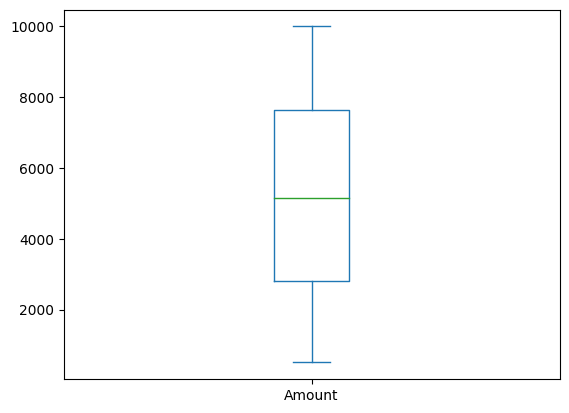

In [13]:
df['Amount'].plot(kind='box')
plt.show()

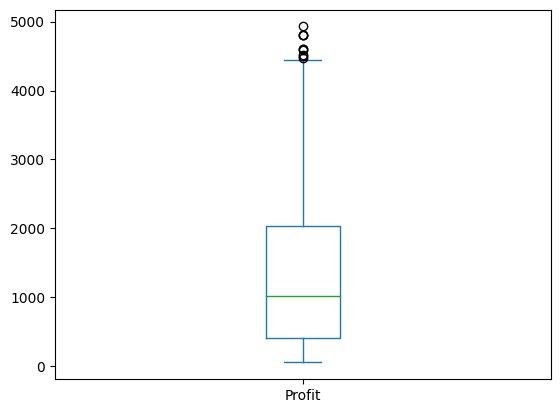

In [14]:
df['Profit'].plot(kind='box')
plt.show()

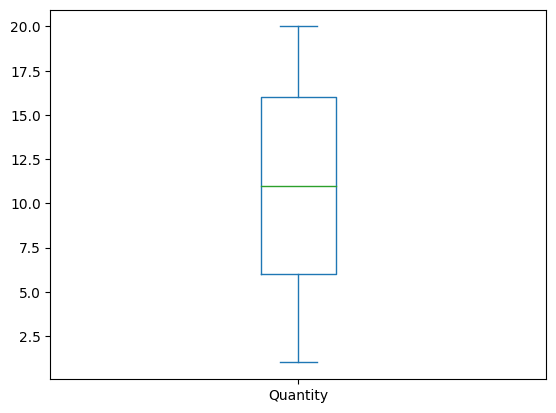

In [15]:
df['Quantity'].plot(kind='box')
plt.show()

## Data visualizations

In [16]:
category_count =df['Category'].value_counts()
category_count

Category
Furniture          407
Office Supplies    399
Electronics        388
Name: count, dtype: int64

In [17]:
explode = (0,0.1,0)

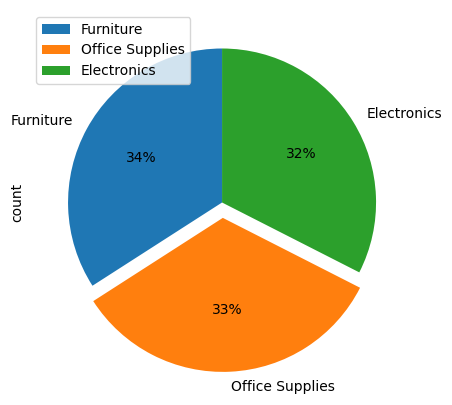

In [18]:
plt.figure(figsize=(10,5))
category_count.plot(kind='pie',explode=explode, autopct= '%1.0f%%', startangle=90)
plt.legend()
plt.show()

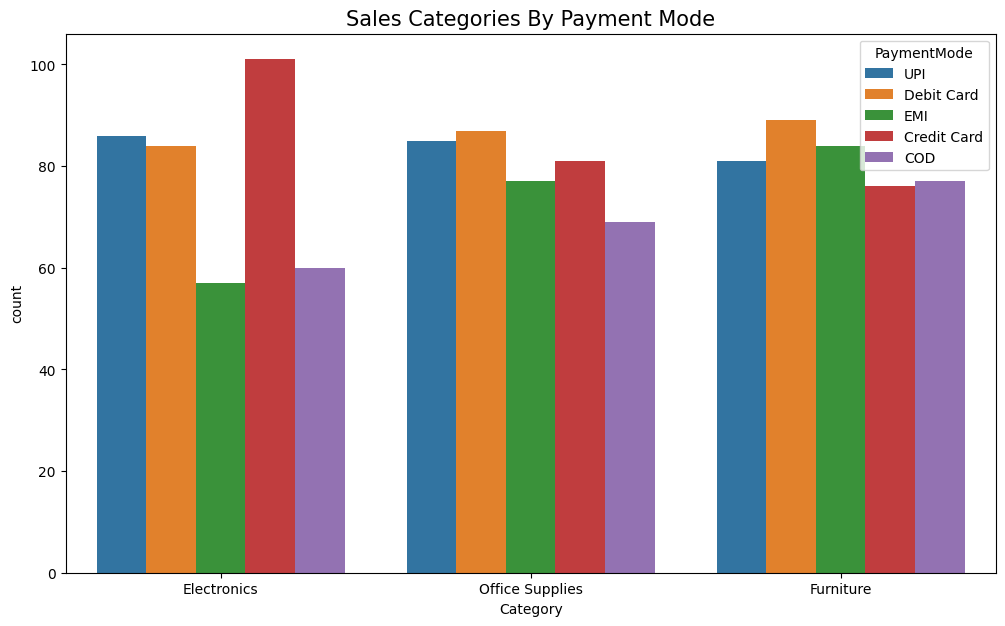

In [19]:
plt.figure(figsize=(12,7))
plt.title('Sales Categories By Payment Mode', fontsize=15)
sns.countplot(x=df['Category'],hue=df['PaymentMode'])
plt.show()

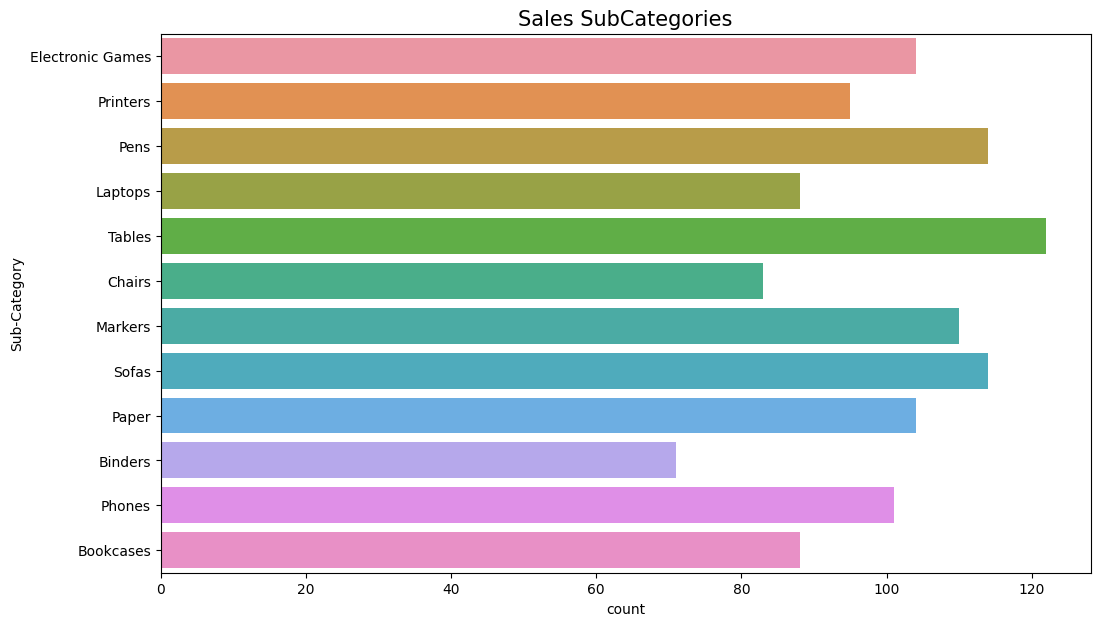

In [20]:
plt.figure(figsize=(12,7))
plt.title('Sales SubCategories', fontsize=15)
sns.countplot(y=df['Sub-Category'])
plt.show()

<Axes: title={'center': 'Distribution of Amount'}, ylabel='Density'>

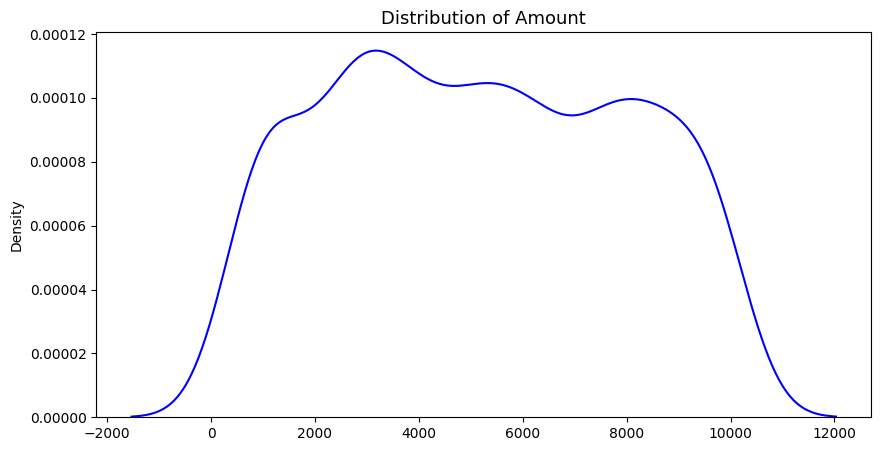

In [21]:
plt.figure(figsize=(10,5))
plt.title('Distribution of Amount',fontsize=13)
sns.distplot(x=df['Amount'], color='blue', hist=False)

<Axes: title={'center': 'Distribution of Profit'}, ylabel='Density'>

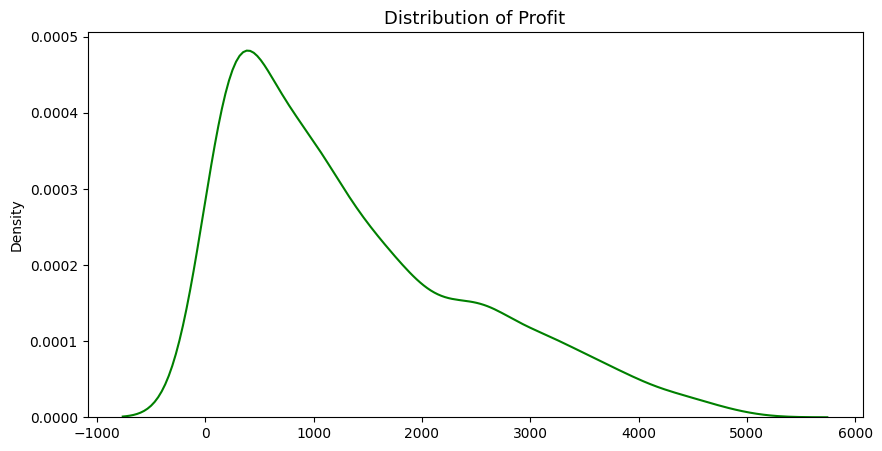

In [22]:
plt.figure(figsize=(10,5))
plt.title('Distribution of Profit',fontsize=13)
sns.distplot(x=df['Profit'], color='green', hist=False)

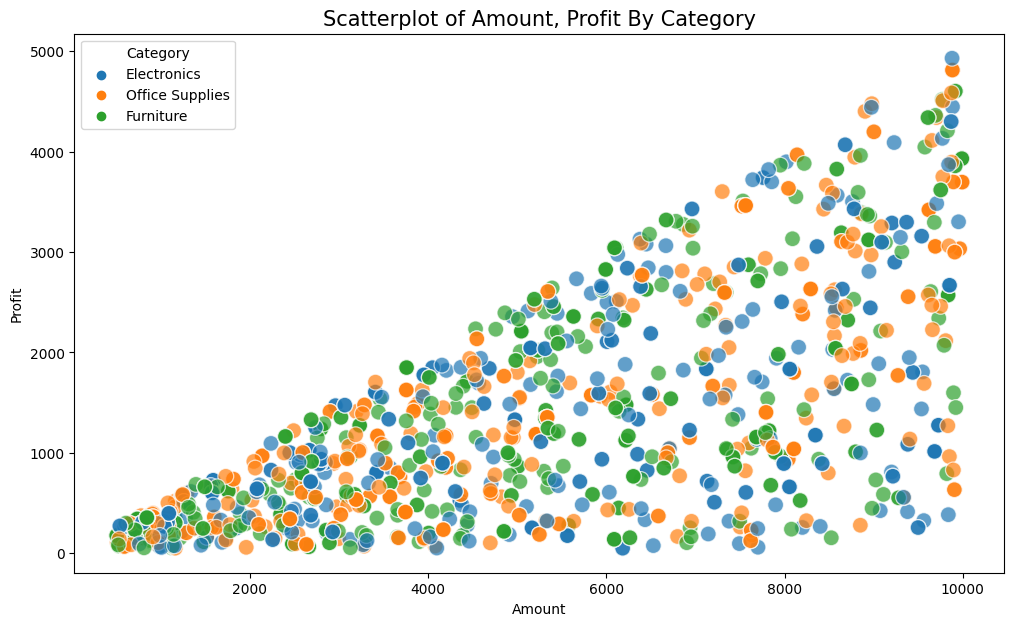

In [23]:
plt.figure(figsize=(12,7))
plt.title('Scatterplot of Amount, Profit By Category', fontsize=15)
sns.scatterplot(data=df, x='Amount', y='Profit', hue='Category', alpha=0.7, s=130)
plt.show()

In [24]:
df.drop(['Order ID', 'Order Date', 'CustomerName', 'Year-Month'], axis=1, inplace=True)
df.dropna(inplace=True)

In [25]:
df

,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,State,City
0,9726,1275,5,Electronics,Electronic Games,UPI,Florida,Miami
1,9726,1275,5,Electronics,Electronic Games,UPI,Illinois,Chicago
2,9726,1275,5,Electronics,Electronic Games,UPI,New York,Buffalo
3,4975,1330,14,Electronics,Printers,UPI,Florida,Miami
4,4975,1330,14,Electronics,Printers,UPI,Illinois,Chicago
...,...,...,...,...,...,...,...,...
1189,8825,3594,15,Furniture,Tables,Debit Card,New York,New York City
1190,2082,642,8,Electronics,Phones,EMI,New York,Rochester
1191,2082,642,8,Electronics,Phones,EMI,Texas,Austin
1192,2082,642,8,Electronics,Phones,EMI,New York,Buffalo


# Encoding Categorical Columns

In [26]:
le = LabelEncoder()

for col in ['Sub-Category', 'PaymentMode', 'State', 'City']:
    df[col] = le.fit_transform(df[col])

# Train Test Split

In [27]:
X = df.drop(columns='Category', axis=1)
y = df['Category']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Building the model

## Logistic regression model

In [29]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [30]:
y_pred = model.predict(X_test)

### Accuracy

In [31]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score: 0.3891


### Confusion matrix

In [32]:
cm = confusion_matrix(y_test, y_pred)

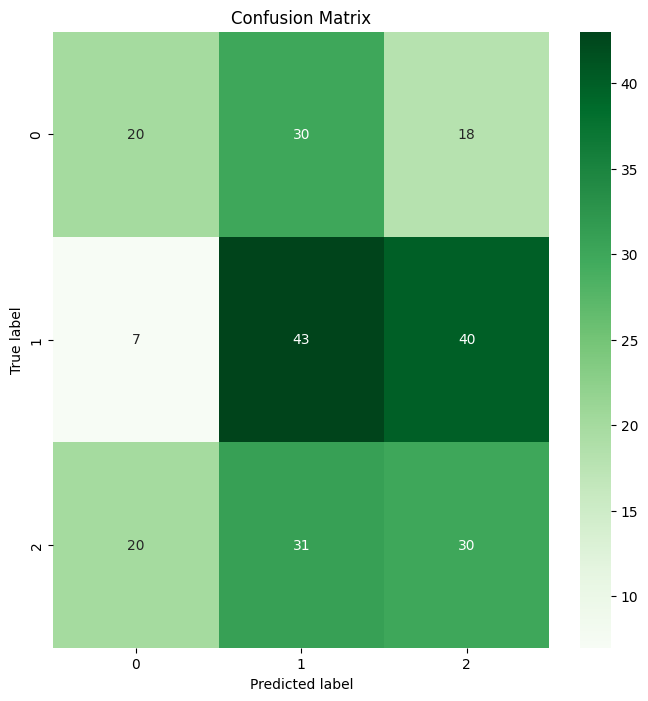

In [33]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## KNN 

In [34]:
from sklearn.neighbors import KNeighborsClassifier


# instantiate the model
knn = KNeighborsClassifier(n_neighbors=3)


# fit the model to the training set
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [35]:
y_knn = knn.predict(X_test)

### Accuracy

In [36]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_knn)))

Model accuracy score: 0.4854


### Confusion matrix

In [37]:
cm1 = confusion_matrix(y_test, y_knn)

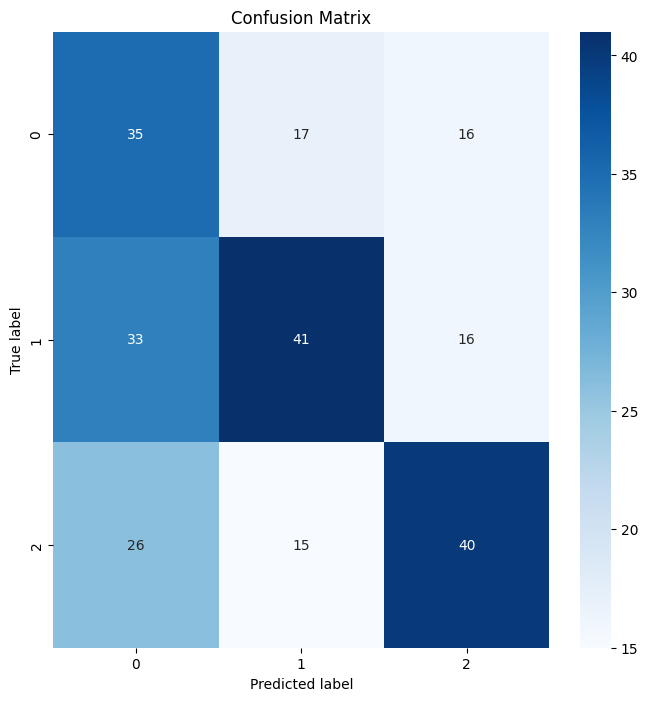

In [38]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## Random Forest

In [39]:
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [40]:
y_pred1 = classifier.predict(X_test)

### Accuracy

In [41]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_pred1)))

Model accuracy score: 0.9958


### Confusion matrix

In [42]:
cm2 = confusion_matrix(y_test, y_pred1)

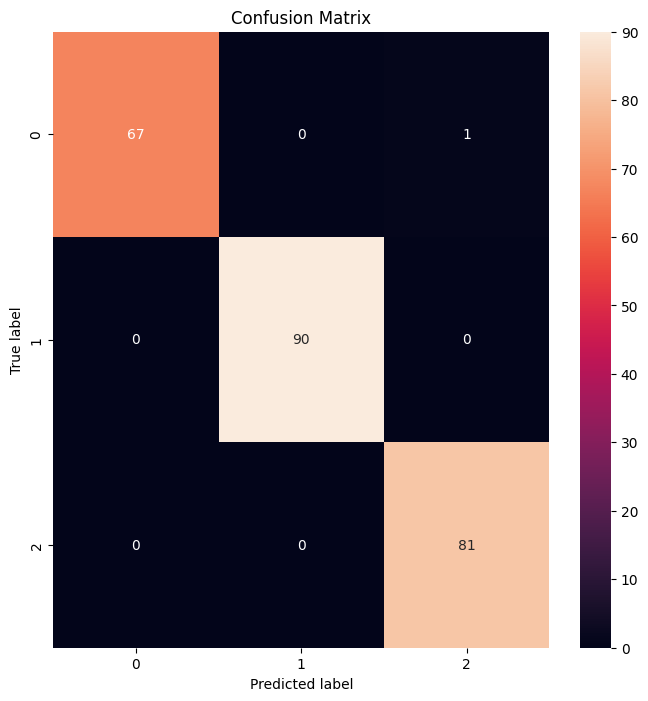

In [43]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm2, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## Decision tree

In [44]:
from sklearn import tree

In [45]:
clf = tree.DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_tree = clf.predict(X_test)

### Accuracy

In [46]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_tree)))

Model accuracy score: 1.0000


### Confusion matrix

In [47]:
cm3 = confusion_matrix(y_test, y_tree)

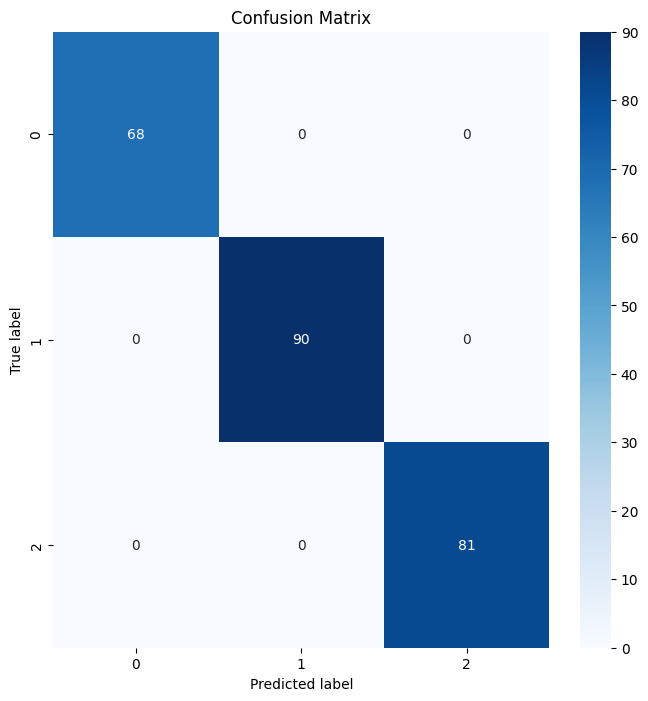

In [48]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## Naive bayes

In [49]:
from sklearn.naive_bayes import GaussianNB
# instantiate the model
gnb = GaussianNB()
# fit the model
gnb.fit(X_train, y_train)

GaussianNB()

In [50]:
y_naive = gnb.predict(X_test)

### Accuracy

In [51]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_naive)))

Model accuracy score: 0.4854


### Confusion matrix

In [52]:
cm4 = confusion_matrix(y_test, y_naive)

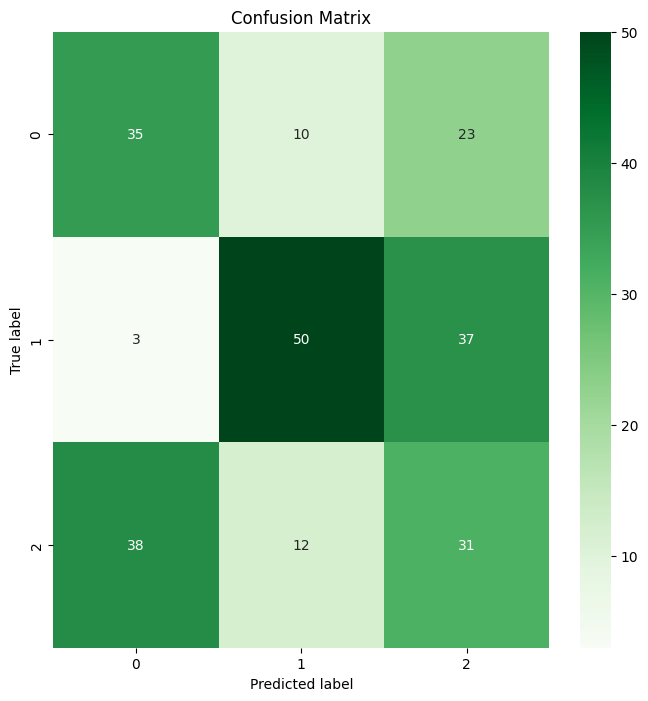

In [53]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm4, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

## svm

In [54]:
svc=SVC() 
svc.fit(X_train,y_train)

SVC()

In [55]:
y_svm=svc.predict(X_test)

### Accuracy

In [56]:
print('Model accuracy score: {0:0.4f}'. format(accuracy_score(y_test, y_svm)))

Model accuracy score: 0.3305


### Confusion matrix

In [57]:
cm5 = confusion_matrix(y_test, y_svm)

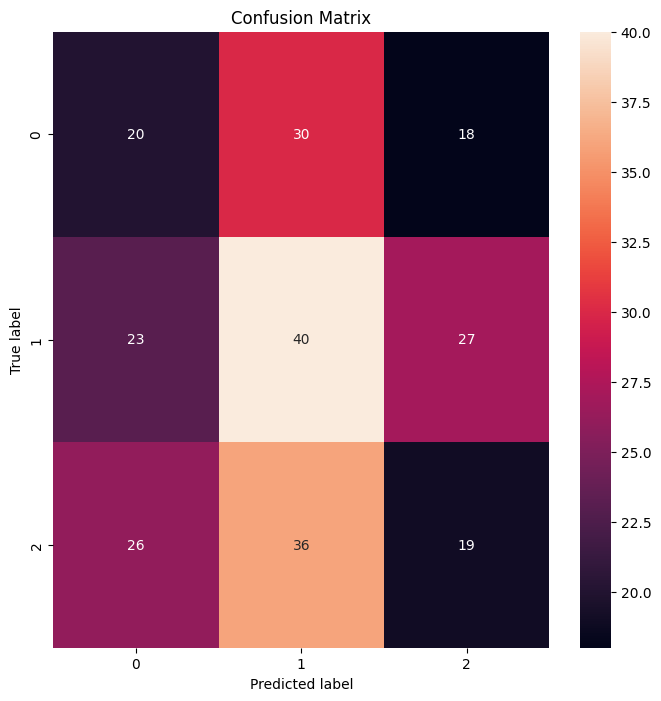

In [58]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm5, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()